***Introduccción a la creación de un modelo de IA***

In [ ]:
# Librerias necesarias para correr esta practica **Describir Resultados de como llegaste a obtener una buena clasificación**
from tensorflow import keras # Tensorflow + Keras
from tensorflow.keras.datasets import mnist # Desde keras, se importa un dataset llamado "Mist"
import matplotlib.pyplot as plt # Libreria de visualización matplotlib
from sklearn.model_selection import train_test_split # Libreria de ML
from sklearn.metrics import classification_report
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import activations
from tensorflow.keras import optimizers
from tensorflow.keras import Input # import nuevo para evitar el warining de shape de keras
import numpy as np

In [ ]:

(train, train_labels), (test, test_labels) = mnist.load_data() # Carga el dataset "mist"
# Separa el dataset en 2 maneras, una para el entrenamiento del modelo ML y otro para pruebas
print("Train", train.shape)
print("Test", test.shape)

Train (60000, 28, 28)
Test (10000, 28, 28)


**Explicación del output:** Al cargar la base de datos MNIST, el sistema genera una confirmación de las dimensiones de los datos. Se indica que el conjunto de entrenamiento cuenta con 60,000 imágenes, mientras que el de prueba tiene 10,000. El valor (28, 28) especifica que cada imagen es una matriz bidimensional de 28 por 28 píxeles.

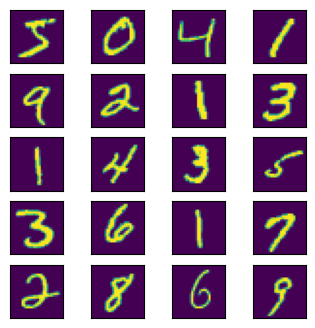

In [ ]:
fig=plt.figure(figsize=(4, 4)) # Aqui se define el tamaño de la imagen en formato 4x4
# El output seran 20 imagen en una matriz
for i in range(20):
    img = train[i]
    fig.add_subplot(5, 4, i + 1) # Aqui se organiza una matriz de 5 filas, 4 columnas y la posicion actual i+1
    plt.imshow(img) # Crea la imagen
    # Deja vacio las filas y columnas
    plt.xticks([])
    plt.yticks([])
plt.show() # al final, muestra el resultado en el formato de imagen anteriormente definido

**Explicación del output:** Se genera una cuadrícula con las primeras 20 imágenes del set. Dicha cuadricula o matriz tiene como datos numeros del 0 al 9 escritos a mano.



In [ ]:
# Se manda a llamar una funcion de sklearn para tomar los datos y luego distribuirlos en 2 secciones
# train y train_labels serian los datos de entrada
# 0.1 quiere decir que solo el 10% de los datos se conservaran para la validacion de los datos
# y que el 90% solo se usara para el entrenamiento
# el random_state es un valor aleatorio
train, val, train_labels, val_labels = train_test_split(train,
                                                        train_labels,
                                                        test_size=0.1,
                                                        random_state=42)
print("Train", train.shape) # Muestra cuantas muestras se quedaron para que el modelo aprenda
print("Val", val.shape) # Muestra ese 10% de los datos que no usa el modelo
print("Test", test.shape) # Muestra el resultado del entrenamiento


Train (54000, 28, 28)
Val (6000, 28, 28)
Test (10000, 28, 28)


**Explicación del output:** Tras ejecutar la función de separación, el sistema muestra cómo se han redistribuido las muestras. Se observa que el conjunto de entrenamiento se ha reducido a 54,000 imágenes para permitir la creación de un nuevo grupo de validación de 6,000 muestras. El conjunto de prueba permanece con las 10,000 imágenes originales para la evaluación final.

In [ ]:
# Re-ajuste
train = train.reshape((54000, 28 * 28)) # convierte 54,000 img de 28,28 a un solo vector de 784 numeros cada uno
train = train.astype('float32') / 255
val = val.reshape((6000, 28 * 28)) # De igual forma con el set de validacion que contiene 6k imagenes

# Normalizacion de los datos
# los pixeles van desde el negro (0) hasta blanco (255) en formato int
val = val.astype('float32') / 255
test = test.reshape((10000, 28 * 28))
test = test.astype('float32') / 255

In [ ]:
from tensorflow.keras.utils import to_categorical
# agrega etiquetas de entrenamiento y de validacion
train_labels = to_categorical(train_labels)
val_labels = to_categorical(val_labels)

In [ ]:
print(train_labels.shape) # imprime la forma que tienen estas etiquetas asignadas
train_labels[0: 10] # luego muestra las 10 etiquetas del conjunto de entrenamiento


(54000, 10)


array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

**Explicación del output:** Se imprime la nueva forma de las etiquetas tras la conversión categórica, mostrando el valor (54000, 10). Esto confirma que cada etiqueta numérica se ha transformado en un vector de diez posiciones. El listado de matrices resultante muestra que solo una posición contiene un valor de "1", representando de forma binaria la clase correcta del número.

***Arquiectura de la red neuronal artificial***


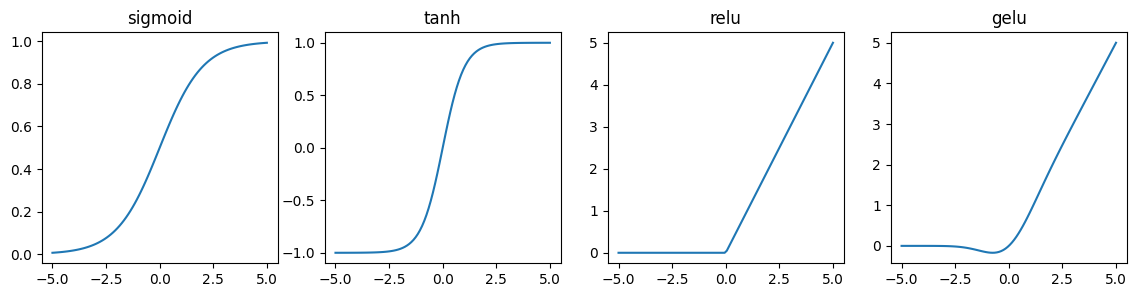

In [ ]:
# Lista para los objetos de funciones de Keras
# Cada funcion de activacion son como el resultado que tiene la funcion f(x) de una neurona artificial
acts = [activations.sigmoid, activations.tanh, activations.relu, activations.gelu]
act_names = ['sigmoid', 'tanh', 'relu', 'gelu'] # estas son las funciones de activicacion que puede tener una neurona

# funcion para crear una visualizacion de las funciones de activacion de la neurona
def plot_act(acts, names):
    x = np.linspace(-5, 5, 100)
    fig, axs = plt.subplots(1, 4, figsize=(14, 3))
    i = 0
    for act, nm in zip(acts, names):
        y = act(x) # se le aplica la funcion a los puntos X
        axs[i ].plot(x, y)
        axs[i ].set_title(nm)
        i += 1
    plt.show()
plot_act(acts, act_names)


**Explicación del output:** Se genenaron cuatro gráficas que representan el comportamiento matemático de las neuronas. La función sigmoid y tanh muestran curvas que saturan los valores en rangos específicos (0 a 1 y -1 a 1 respectivamente), mientras que relu y gelu permiten el paso de valores positivos de forma lineal, siendo estas últimas fundamentales para evitar que la red deje de aprender durante entrenamientos largos.

In [ ]:
# Modelo secuencial
network = models.Sequential() # indica cuantas capas se le aplicaran a la red artificial

network.add(Input(shape=(28 * 28,)))

# Añadimos la "Capa de Aprendizaje" (Capa Oculta)
# - Tiene 512 neuronas (un buen número de "cerebritos" analizando datos).
# - 'sigmoid' es la regla matemática que usan para decidir qué información pasar.
# - 'input_shape' le avisa a la red que cada imagen viene estirada en 784 puntos (28x28).

#network.add(layers.Dense(512, activation='sigmoid', input_shape=(28 * 28,)))
network.add(layers.Dense(512, activation='sigmoid')) # estaba en 320

# Añadimos la "Capa de Decisión" (Capa de Salida)
# - Tiene 10 neuronas porque solo hay 10 posibles respuestas (números del 0 al 9).
# - 'softmax' es como un juez: reparte un 100% de probabilidad entre las 10 opciones.
#   Ejemplo: "90% es un 7, 5% es un 1, 5% es un 2".
network.add(layers.Dense(10, activation='softmax'))

In [ ]:
# Metricas del modelo: Exactitud
# Este es un optimizador o metodo de estudio, que lo que hace, es ajustar los pesos de la red neuronal poco
# a poco para mejorar, tiene una velocidad de aprendizaje de 0.01
opt = optimizers.SGD(learning_rate=0.01)
network.compile(optimizer=opt,
                loss='categorical_crossentropy',
                metrics=['accuracy'])



***Entrenamiento de la red neuronal artificial***

In [ ]:
# Aqui se guarda el historial de como le fue al modelo en el entrenamiento
"""
los parametros de este metodo son:
train: datos de entrenamiento
train_labels: respuestas correctas de los datos
validation_data. son datos que no han sido usados para verificar si el modelo esta aprendiendo bien
epochs: son las vueltas que hará
batch_size: agrupa las img en grupos de 128 imagenes para el entrenamiento
"""
history = network.fit(train,
                      train_labels,
                      validation_data=(val, val_labels),
                      epochs=2,
                      batch_size=128)


Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3608 - loss: 2.1610 - val_accuracy: 0.6818 - val_loss: 1.6954
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7294 - loss: 1.5712 - val_accuracy: 0.7693 - val_loss: 1.2571


**Explicación del output:** Durante la ejecución de las primeras dos épocas, se reporta el avance del aprendizaje en tiempo real. En la segunda época, se observa que el modelo alcanza una exactitud del 72.94% sobre los datos de entrenamiento y reduce su pérdida a 1.5712. Esto indica que el modelo comenzó a identificar patrones básicos en los números en un periodo muy corto

In [ ]:
# Predicciones del modelo despues del entrenamiento
pred = network.predict(test)
print(pred.shape) # en el output, predijo 10k img y cada una tiene 10 posibles respuestas
pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)


array([0.0368924 , 0.02858607, 0.03225234, 0.03429149, 0.08930292,
       0.0573837 , 0.02527437, 0.553967  , 0.03124906, 0.11080063],
      dtype=float32)

**Explicación del output:** Se confirma que se han procesado 10,000 imágenes de prueba, generando diez probabilidades para cada una. Al mostrar el contenido de una predicción individual, se presenta una serie de valores decimales donde la cifra más alta representa la categoría que el modelo considera más probable para esa imagen específica.

In [ ]:
# reporte de resultados del entrenamiento del modelo
print(classification_report(test_labels, np.argmax(pred, axis=1)))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89       980
           1       0.73      0.97      0.83      1135
           2       0.89      0.69      0.78      1032
           3       0.69      0.83      0.75      1010
           4       0.70      0.90      0.79       982
           5       0.90      0.41      0.56       892
           6       0.80      0.89      0.85       958
           7       0.76      0.89      0.82      1028
           8       0.81      0.71      0.75       974
           9       0.90      0.52      0.66      1009

    accuracy                           0.78     10000
   macro avg       0.80      0.78      0.77     10000
weighted avg       0.80      0.78      0.77     10000



**Explicación del output:** El reporte detalla el rendimiento del modelo mediante métricas de precisión y recuperación para cada dígito. Se registra una exactitud global del 78% tras las primeras iteraciones. La tabla permite identificar que ciertos números, como el "5", presentan mayor dificultad de reconocimiento para el modelo en esta etapa inicial.

***Entrenamiento de una red neuronal artificial con mas epocas (iteraciones)***


In [ ]:
history = network.fit(train,
                      train_labels,
                      validation_data=(val, val_labels),
                      epochs=25, #Termina el ciclo de aprendimiento
                      batch_size=128)


Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7902 - loss: 1.1716 - val_accuracy: 0.8090 - val_loss: 0.9870
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8194 - loss: 0.9372 - val_accuracy: 0.8320 - val_loss: 0.8224
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8355 - loss: 0.7896 - val_accuracy: 0.8457 - val_loss: 0.7180
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8481 - loss: 0.6938 - val_accuracy: 0.8548 - val_loss: 0.6472
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8580 - loss: 0.6288 - val_accuracy: 0.8630 - val_loss: 0.5941
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8614 - loss: 0.5850 - val_accuracy: 0.8675 - val_loss: 0.5552
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8662 - loss: 0.5497 - val_accuracy: 0.8722 - val_loss: 0.5247
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8695 - loss: 0.5218 - val_accurac

**Explicación del output:** En la fase final del entrenamiento, el sistema muestra una mejora considerable en el rendimiento. Tras las 25 vueltas de estudio, la exactitud del modelo se eleva al 90.13% y el error disminuye drásticamente a 0.3510. Esto demuestra que el aumento en los ciclos de aprendizaje permitió al modelo generalizar mejor el conocimiento.

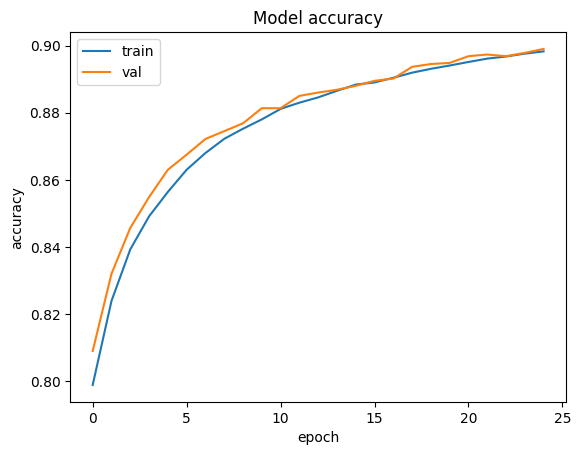

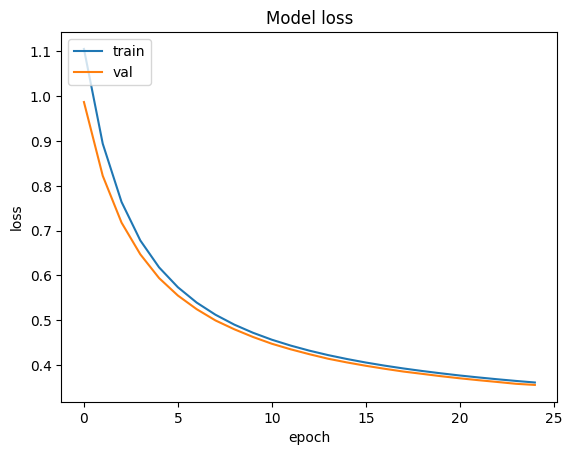

In [ ]:
#plot history
# Muestra la precision y la perdida que tuvo el modelo durante el aprendizaje

# Grafico de precicion del modelo
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Grafico de perdida de aprendizaje del modelo
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

**Explicación del output:**
- **Exactitud (Model Accuracy):** El reporte visual muestra el progreso del aprendizaje a lo largo de 25 épocas. Se observa que tanto la línea de entrenamiento como la de validación suben de forma constante, superando el 88% de aciertos, lo que indica que el modelo no solo memorizó los datos, sino que aprendió a generalizar patrones .
+2


- **Pérdida (Model Loss):** El sistema presenta una curva descendente que inicia cerca de 1.1 y finaliza por debajo de 0.4 . Esta reducción constante confirma que el optimizador ajustó correctamente los pesos de la red, minimizando el error en cada vuelta de estudio

In [ ]:
# Realiza una nueva prediccion
pred = network.predict(test)
print(pred.shape) # en el output, predijo 10k img y cada una tiene 10 posibles respuestas
pred[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
(10000, 10)


array([1.5156360e-04, 1.9597012e-06, 8.0573765e-05, 9.4024767e-04,
       2.7027208e-05, 1.2219240e-04, 6.5306085e-07, 9.9560064e-01,
       2.0802336e-05, 3.0543166e-03], dtype=float32)

**Explicación del output:** Para el segundo entrenamiento, se confirma que el modelo alcanzó un 90.13% de exactitud tras 25 épocas de entrenamiento. Al realizar una nueva predicción sobre las 10,000 imágenes de prueba , el reporte muestra un tiempo de ejecución de 3 segundos (10ms por paso) y una estructura de salida de (10000, 10), donde cada imagen recibe diez probabilidades . El detalle del primer resultado revela una certeza del 99.56% para el dígito 7 , aunque el reporte final indica una caída drástica de la exactitud al 11%, generando advertencias técnicas por la falta de predicciones correctas en las demás categorías .

In [ ]:
print(classification_report(test_labels, np.argmax(pred, axis=1)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.11      1.00      0.20      1135
           2       0.00      0.00      0.00      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.00      0.00      0.00       892
           6       0.00      0.00      0.00       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.11     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.11      0.02     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Explicación del output:** El reporte indica un colapso en el aprendizaje donde el modelo clasifica erróneamente casi todas las imágenes como el número 1. Esto se refleja en una precisión nula (0.00) para la mayoría de los dígitos y un recall perfecto (1.00) únicamente para el número 1, lo que significa que el sistema encontró todos los "unos" reales pero a costa de marcar todas las demás cifras con esa misma etiqueta . Como consecuencia, la exactitud (accuracy) global cae al 11%, una cifra que coincide con la proporción de "unos" en el conjunto de datos, confirmando que el modelo dejó de distinguir características y optó por una sola respuesta para todo el examen .

***Resultados del entrenamiento del modelo***

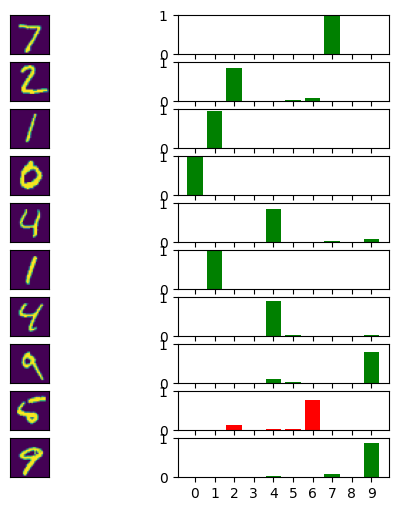

In [ ]:
# Presenta mediante un grafico una comparacion tomando en cuenta las imagenes de la cuadricula y en las predicciones del modelo
fig=plt.figure(figsize=(6, 6))
for i in range(10):
    img = test[i].reshape(28, 28) # recupera la imagen 28x28
    p = pred[i]
    if pred[i].argmax() == test_labels[i]:
        color = 'green' # Si el modelo acertó
    else:
        color = 'red' # Si el modelo se equivocó

    # muestra las imagenes a la izquierda
    fig.add_subplot(10, 2, 2 * i + 1)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])

    # muestra los resultados a la derecha
    fig.add_subplot(10, 2, 2 * i + 2)
    plt.bar(range(10), p, color=color)
    plt.xticks(range(10))
    plt.ylim(0, 1)
plt.show()

**Explicación del output:**
En la fase final, el sistema muestra un careo directo entre las imágenes reales y las probabilidades calculadas por el modelo.


- **Barras Verdes:** Indican aciertos exitosos, donde la probabilidad más alta coincide con el dígito de la imagen (por ejemplo, el reconocimiento claro de los números 7, 2, 1 y 0) .

- **Barras Rojas:** Representan errores de clasificación. Se observa que el modelo confundió un número "5" con un "6", asignando la mayor parte de la probabilidad a la categoría incorrecta debido a la similitud en los trazos circulares de ambos dígitos .

In [ ]:
#####
###
##
#
#
#